# **ESG-Based Portfolio Optimization: Building a Sustainable S&P 500 Fund**

### *MGSC 404 - Final project*

In this project, we develop a data-driven framework for constructing an **ESG-oriented equity fund** based on companies listed in the **S&P 500 index**.  
The objective is to design a portfolio that **maximizes expected return** while integrating key principles of **sustainability, risk management, and diversity**. Using financial and ESG data from Kaggle, we aim to apply **optimization techniques in Python**—with a focus on **linear programming (LP)** using **Gurobi**—to identify the optimal allocation of a **100 million USD fund** across selected companies.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gurobipy as gp
from gurobipy import GRB

### **1.0 - Importing, merging and creating the full dataset**

In [2]:
# Import all the datasets
price_df = pd.read_csv("sp500_price_data.csv")
esg_df = pd.read_csv("sp500_esg_data.csv")
esg_ceo_df = pd.read_csv("sp500_esg_ceo_info-filtered.csv")
esg_risk_df = pd.read_csv("SP 500 ESG Risk Ratings.csv")

In [3]:
# Harmonize all the tickers column for the merge
corrected_esg_df = esg_df.rename(columns={"Symbol":"Ticker"})
corrected_esg_risk = esg_risk_df.rename(columns={"Symbol":"Ticker"})

# Merge of all the informative datasets
intermediate_df = corrected_esg_df.merge(esg_ceo_df, on="Ticker")
full_informative_df = intermediate_df.merge(corrected_esg_risk, on="Ticker")

In [4]:
# Convert to datetime
price_df["Date"] = pd.to_datetime(price_df["Date"], errors="coerce")

# Inversion of the dataset
corrected_price_df = price_df.melt(
    id_vars = "Date",
    var_name = "Ticker",
    value_name = "Price")

# Cleaning and creation of the price data (return + volatility)
corrected_price_df = corrected_price_df.dropna(subset=["Ticker","Price"])
corrected_price_df = corrected_price_df.sort_values(["Ticker","Date"])
corrected_price_df["Daily Return"] = corrected_price_df.groupby("Ticker")["Price"].pct_change()
corrected_price_df = corrected_price_df.dropna(subset="Daily Return")

expected_annual_return = ((1 + corrected_price_df.groupby('Ticker')['Daily Return'].mean())**252 - 1)
expected_annual_return.name = "Expected Annual Return"

annual_volatility = (corrected_price_df.groupby("Ticker")["Daily Return"].std() * np.sqrt(252))
annual_volatility.name = "Annual Volatility"

combined_data = pd.concat([expected_annual_return, annual_volatility], axis=1).reset_index()

In [5]:
# Merging and creation of the final usable dataset for the project
full_df = full_informative_df.merge(combined_data, on="Ticker")
full_df = full_df.dropna(axis=1, how="any")
final_df = full_df[["Ticker", "Full Name", "GICS Sector", "Expected Annual Return", "Annual Volatility", "marketCap", 
                     "environmentScore", "socialScore","governanceScore", "totalEsg", "highestControversy", "overallRisk", 
                     "CEO Gender"]]
final_df.head()

,Ticker,Full Name,GICS Sector,Expected Annual Return,Annual Volatility,marketCap,environmentScore,socialScore,governanceScore,totalEsg,highestControversy,overallRisk,CEO Gender
0,A,Agilent Technologies,Health Care,0.006333,0.266966,39751831552,1.12,6.42,6.10,13.64,2.0,8,male
1,AAL,American Airlines Group,Industrials,-0.034155,0.387437,7335383552,9.94,11.65,4.76,26.35,2.0,10,male
2,AAPL,Apple Inc.,Information Technology,0.475624,0.217940,3296096681984,0.46,7.39,9.37,17.22,3.0,1,male
3,ABBV,AbbVie,Health Care,0.144086,0.199241,341698445312,2.38,17.19,10.36,29.93,3.0,6,male
4,ABT,Abbott Laboratories,Health Care,0.039482,0.194039,205534380032,2.27,14.24,8.33,24.83,3.0,7,male


### **2.0 - Exploratory Data Analysis**

In [6]:
# Check the shape of the dataset
final_df.shape

(414, 13)

In [7]:
# Display schema: field names and data types
schema_df = (
    final_df.dtypes
    .reset_index()
    .rename(columns={"index": "Field", 0: "DataType"})
)
display(schema_df)

,Field,DataType
0,Ticker,object
1,Full Name,object
2,GICS Sector,object
3,Expected Annual Return,float64
4,Annual Volatility,float64
5,marketCap,int64
6,environmentScore,float64
7,socialScore,float64
8,governanceScore,float64
9,totalEsg,float64


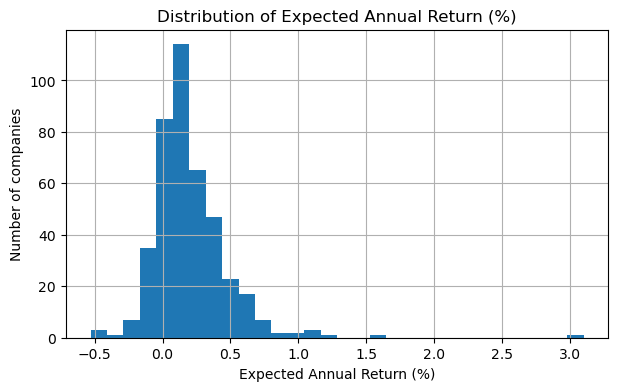

In [8]:
# Graph 1 - Distribution of the expected annual return
plt.figure(figsize=(7,4))
plt.hist(final_df["Expected Annual Return"], bins=30)
plt.grid(True)
plt.xlabel("Expected Annual Return (%)")
plt.ylabel("Number of companies")
plt.title("Distribution of Expected Annual Return (%)")
plt.show()

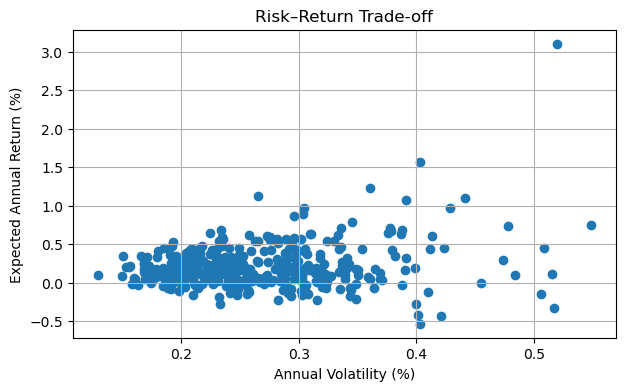

In [9]:
# Graph 2 - Risk/Return trade-off
plt.figure(figsize=(7,4))
plt.scatter(x=final_df["Annual Volatility"], y=final_df["Expected Annual Return"])
plt.grid(True)
plt.title("Risk–Return Trade-off")
plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.show()

<Figure size 2200x700 with 0 Axes>

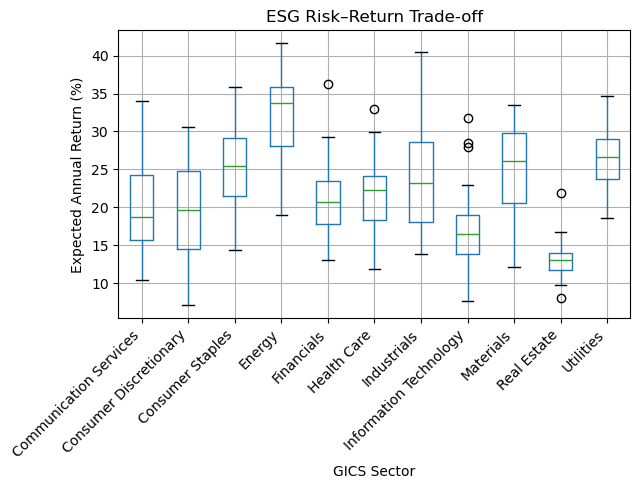

In [10]:
# Graph 3 - ESG Scores by sector
plt.figure(figsize=(22, 7))
final_df.boxplot(column="totalEsg", by="GICS Sector")
plt.title("ESG Risk–Return Trade-off")
plt.suptitle("")
plt.xlabel("GICS Sector")
plt.ylabel("Expected Annual Return (%)")
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.3)
plt.grid(True)
plt.show()

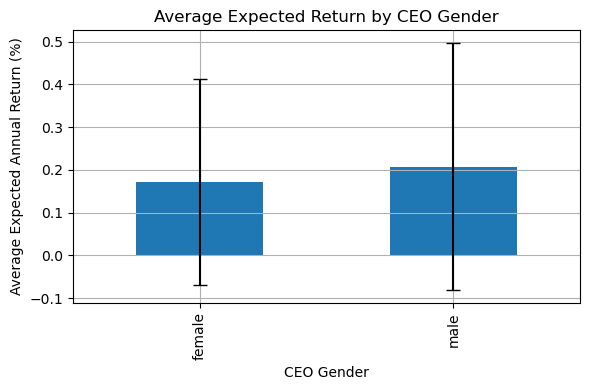

In [11]:
# Graph 4 - Average expected annual return by gender
average_gender_return = final_df.groupby("CEO Gender")["Expected Annual Return"].mean()
average_gender_return.name = "Average Gender Return"
gender_std = final_df.groupby("CEO Gender")["Expected Annual Return"].std()
gender_std = gender_std.reindex(average_gender_return.index)

plt.figure(figsize=(6, 4))
average_gender_return.plot(kind="bar", yerr=gender_std, capsize=5)

plt.title("Average Expected Return by CEO Gender")
plt.xlabel("CEO Gender")
plt.ylabel("Average Expected Annual Return (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


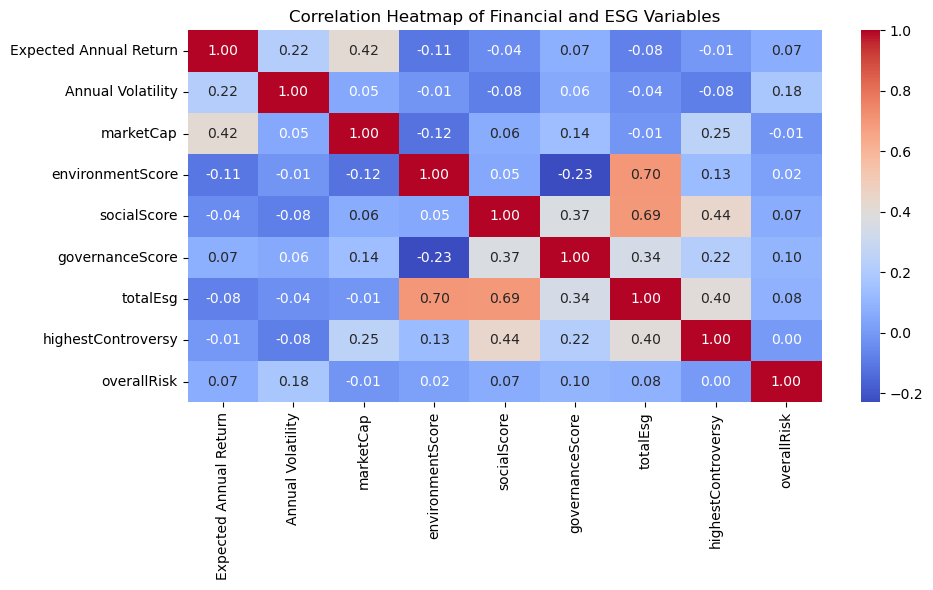

In [12]:
# Graph 5 - Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(final_df.select_dtypes("number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Financial and ESG Variables")
plt.tight_layout()
plt.show()

### **3.0 - Optimization with Gurobi**

In [13]:
# Set parameters constraints
budget = 0.99
min_weight = 0.01
max_weight = 0.05
max_volatility = 0.30
environment_score = 5
social_score = 5
governance_score = 5
max_marketcap = 2000000000
max_sector_weight = 0.20
min_female_ratio = 0.33

# Verify eligible stocks within the database (SP500) + formatting for the optimization
needed_col = ["Ticker","GICS Sector","Expected Annual Return","Annual Volatility","marketCap",
        "environmentScore","socialScore","governanceScore","CEO Gender"]
opti_df = final_df[needed_col]

selected_stock_mask = (
    (opti_df["Annual Volatility"] <= max_volatility) &
    (opti_df['environmentScore'] >= environment_score) &
    (opti_df['socialScore'] >= social_score) &
    (opti_df['governanceScore'] >= governance_score) &
    (opti_df['marketCap'] >= max_marketcap)
)

opti_df = opti_df[selected_stock_mask]
opti_df

I = opti_df["Ticker"].tolist()
S = opti_df["GICS Sector"].unique().tolist()

return_dict = dict(zip(I, opti_df['Expected Annual Return']))
sector_dict = dict(zip(I, opti_df['GICS Sector']))
is_fem = {
    ticker: 1 if gender == "female" else 0
    for ticker, gender in zip(opti_df['Ticker'], opti_df['CEO Gender'])
}

# optimization code
m = gp.Model("ESG_SP500")

# decision variable
w = {i: m.addVar(lb=0.0, ub=1.0, name=f"w[{i}]") for i in I}     # weighting of the stock
y = {i: m.addVar(vtype=GRB.BINARY, name=f"y[{i}]") for i in I}   # if selected

# set the objective function (in this case, maximize the return)
m.setObjective(gp.quicksum(return_dict[i]*w[i] for i in I), GRB.MAXIMIZE)

# adding constraints

m.addConstr(gp.quicksum(w[i] for i in I) <= budget, name="budget")

for i in I:
    m.addConstr(w[i] >= min_weight * y[i], name=f"min_if_selected[{i}]")
    m.addConstr(w[i] <= max_weight * y[i], name=f"max_if_selected[{i}]")

m.addConstr(gp.quicksum(is_fem[i]*y[i] for i in I) >= min_female_ratio * gp.quicksum(y[i] for i in I), name="female_ceo_ratio")

for s in S:
    m.addConstr(gp.quicksum(w[i] for i in I if sector_dict[i]==s) <= max_sector_weight, name=f"sector_cap[{s}]")

# result + output (Used ChatGPT to make a clean format)

m.Params.OutputFlag = 1
m.optimize()

if m.status == GRB.OPTIMAL:
    res = pd.DataFrame({
        "Ticker": I,
        "Sector": [sector_dict[i] for i in I],
        "Selected": [int(y[i].X) for i in I],
        "Weight": [w[i].X for i in I],
        "ExpReturn": [return_dict[i] for i in I],
        "FemaleCEO": [is_fem[i] for i in I],
    })
    sel = res.query("Selected == 1").sort_values("Weight", ascending=False).reset_index(drop=True)

    budget_used   = sel["Weight"].sum()
    female_count  = int((sel["FemaleCEO"]==1).sum())
    total_count   = int(len(sel))
    female_ratio  = female_count / max(total_count,1)
    sector_share  = sel.groupby("Sector")["Weight"].sum().sort_values(ascending=False)

    print(f"\nObjective (Max Expected Return): {m.objVal:.4%}")
    print(f"Selected stocks: {total_count}  |  Female-CEO: {female_count}  "
          f"(ratio {female_ratio:.0%}  ≥ {min_female_ratio:.0%})")
    print(f"Sum of weights: {budget_used:.4f} (≤ {budget})")
    print("\nSector shares (each ≤ 0.20 expected):")
    print(sector_share)

    display(sel)
else:
    print(f"Model status: {m.status}")




Set parameter Username
Set parameter LicenseID to value 2702543
Academic license - for non-commercial use only - expires 2026-09-03
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.1.0 22A380)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 195 rows, 186 columns and 651 nonzeros
Model fingerprint: 0x59262e3e
Variable types: 93 continuous, 93 integer (93 binary)
Coefficient statistics:
  Matrix range     [1e-02, 1e+00]
  Objective range  [3e-03, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-01, 1e+00]
Found heuristic solution: objective -0.0000000
Presolve removed 40 rows and 29 columns
Presolve time: 0.00s
Presolved: 155 rows, 157 columns, 536 nonzeros
Variable types: 77 continuous, 80 integer (80 binary)

Root relaxation: objective 3.971705e-01, 38 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Object

,Ticker,Sector,Selected,Weight,ExpReturn,FemaleCEO
0,ADI,Information Technology,1,0.05,0.302198,0
1,LEN,Consumer Discretionary,1,0.05,0.574952,0
2,VMC,Materials,1,0.05,0.255226,0
3,TXN,Information Technology,1,0.05,0.216143,0
4,TDG,Industrials,1,0.05,0.648424,0
5,SHW,Materials,1,0.05,0.336736,0
6,PSX,Energy,1,0.05,0.265914,0
7,PNR,Industrials,1,0.05,0.562725,0
8,PH,Industrials,1,0.05,0.604230,1
9,NVR,Consumer Discretionary,1,0.05,0.562244,0


### **4.0 - Creation of the fund (normalizing) + Graphical representation**

Number of data : 417 days

        Date  IndexReturn  IndexLevel
0 2023-01-04     0.019976  101.997607
1 2023-01-05    -0.007668  101.215488
2 2023-01-06     0.029526  104.203989
3 2023-01-09    -0.001747  104.021973
4 2023-01-10     0.006539  104.702136


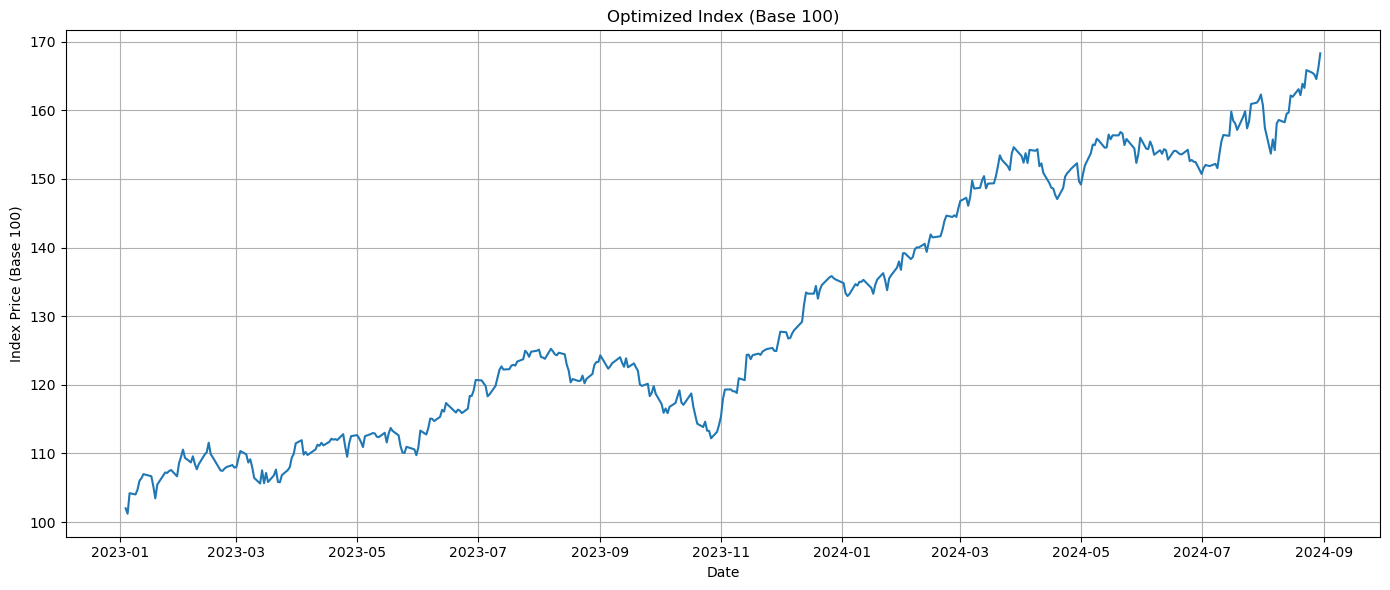

In [14]:
# Creation of our new variable containing our optimized stock selection
fund = sel

# Structuring of the fund
ticker_weight_dict = dict(zip(fund["Ticker"], fund["Weight"]))

ticker_return_dict = {}
for i in range(corrected_price_df.shape[0]):
    if corrected_price_df.iloc[i]["Ticker"] in ticker_weight_dict:
        if corrected_price_df.iloc[i]["Ticker"] not in ticker_return_dict:
            ticker_return_dict[corrected_price_df.iloc[i]["Ticker"]] = []
            ticker_return_dict[corrected_price_df.iloc[i]["Ticker"]].append(float(corrected_price_df.iloc[i]["Daily Return"]))
        else:
            ticker_return_dict[corrected_price_df.iloc[i]["Ticker"]].append(float(corrected_price_df.iloc[i]["Daily Return"]))

date_list = []
for date in corrected_price_df["Date"].unique():
    date_list.append(date.strftime("%Y-%m-%d"))

tickers = list(ticker_weight_dict.keys())

T = len(date_list)     # sanity check if the number of dates corresponds to the number of returns
print(f"Number of data : {T} days")

for ticker in tickers:
    if ticker not in ticker_return_dict:
        ticker_return_dict[ticker] = [0.0] * T
    else:
        vals = [float(x) for x in ticker_return_dict[ticker]]
        if len(vals) < T:
            vals = vals + [0.0] * (T - len(vals))
        elif len(vals) > T:
            vals = vals[:T]
        ticker_return_dict[ticker] = vals

R = np.column_stack([ticker_return_dict[ticker] for ticker in tickers])  
w = np.array([float(ticker_weight_dict[ticker]) for ticker in tickers])

wsum = w.sum()
if wsum != 0:
    w = w / wsum

index_return = R @ w 

index_level = 100 * np.cumprod(1 + index_return)

index_df = pd.DataFrame({
    "Date": pd.to_datetime(date_list),
    "IndexReturn": index_return,
    "IndexLevel": index_level
}).sort_values("Date").reset_index(drop=True)

print()
print(index_df.head())

# Graph creation
plt.figure(figsize=(14, 6))
plt.plot(index_df["Date"], index_df["IndexLevel"]);
plt.title("Optimized Index (Base 100)")
plt.xlabel("Date")
plt.ylabel("Index Price (Base 100)")
plt.grid(True)
plt.tight_layout()
plt.show()
    

### **5.0 - Computing the VaR**

In [15]:
r = np.array(index_return)

alpha = 0.95
var_1d = -np.quantile(r, 1 - alpha)
print("VaR 1-day (95%) =", var_1d)

VaR 1-day (95%) = 0.013755255019349755


In [16]:
h = 10
var_hd = var_1d * np.sqrt(h)
print(f"VaR {h}-day (95%) =", var_hd)

VaR 10-day (95%) = 0.043497935657608705


In [17]:
from scipy.stats import norm      # this library is needed for the ppf function

alpha = 0.95
mu = np.mean(r)
sigma = np.std(r, ddof=1)

var_1d = -(mu + sigma * norm.ppf(1 - alpha))
print("Parametric VaR 1-day (95%) =", var_1d)

Parametric VaR 1-day (95%) = 0.012960555250771076


In [18]:
V = 100_000_000
var_value = V * var_1d
print("VaR in $ =", var_value)

VaR in $ = 1296055.5250771076


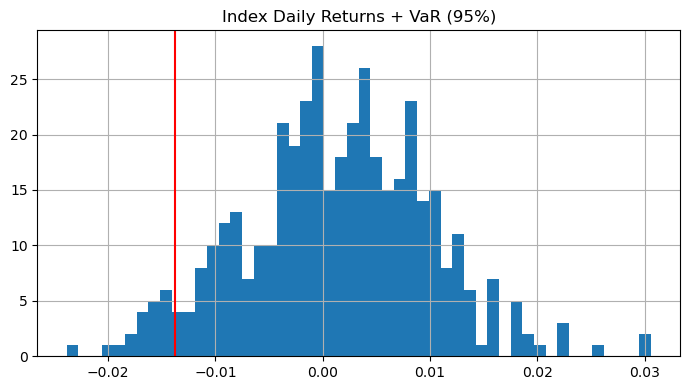

In [19]:
alpha = 0.95
var_1d = -np.quantile(r, 1-alpha)

plt.figure(figsize=(7,4))
plt.hist(r, bins=50)
plt.axvline(-var_1d, color="red")
plt.title("Index Daily Returns + VaR (95%)")
plt.grid(True)
plt.tight_layout()
plt.show()

### **6.0 - Computing the ES (under FRTB regulation)**

In [20]:
r = np.array(index_return)
alpha = 0.975               #confidence level from the FRTB regulation
V = 100_000_000
var_1d = np.quantile(r, 1-alpha)

losses_beyond_var_1d = []

for returns in r:
    if returns < var_1d:
        losses_beyond_var_1d.append(returns)

losses_array = np.array(losses_beyond_var_1d)
expected_shortfall = losses_array.mean()*V
print(f"Expected Shortfall (ES) under FRTB regulation : {round(expected_shortfall,2)}$")

Expected Shortfall (ES) under FRTB regulation : -1795047.51$
